**This SupCons uses TF-IDF**

In [1]:
import pandas as pd 
import numpy as np 
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from torch import nn
from timeit import default_timer as timer
from scipy import sparse
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

**Data Loading**

In [2]:
df = pd.read_csv("D:\\temp dataset\\malware_api_class-master\\malware_api_class-master\\all_analysis_data.txt",header=None)


**PreProcess**

In [3]:
docs = df[0].str.lower().to_list()

vectorizer = TfidfVectorizer(ngram_range=(3, 5),smooth_idf=True, norm="l2", sublinear_tf=True,
                             max_df=.9,)

transformed  = vectorizer.fit_transform(docs)

print(type(transformed))

print(vectorizer.get_feature_names_out())

<class 'scipy.sparse._csr.csr_matrix'>
['__anomaly__ ntclose ntclose'
 '__anomaly__ ntclose ntclose ntfreevirtualmemory'
 '__anomaly__ ntclose ntclose ntfreevirtualmemory ntfreevirtualmemory' ...
 'wsastartup wsastartup wsastartup wsastartup ntdelayexecution'
 'wsastartup wsastartup wsastartup wsastartup select'
 'wsastartup wsastartup wsastartup wsastartup wsastartup']


In [4]:
print(len(vectorizer.get_feature_names_out()))
print(transformed.shape)

442695
(7107, 442695)


In [5]:
uniqe_Api = {'ldrloaddll': 433348, 'ldrgetprocedureaddress': 2215553, 'regopenkeyexa': 286556, 'ntopenkey': 214822, 'ntqueryvaluekey': 197671, 'ntclose': 7022327, 'ntqueryattributesfile': 12509, 'loadstringa': 258176, 'ntallocatevirtualmemory': 3877058, 'ldrgetdllhandle': 2383612, 'ldrunloaddll': 48725, 'findfirstfileexw': 4094715, 'copyfilea': 3257278, 'regcreatekeyexa': 168919, 'regsetvalueexa': 372783, 'regclosekey': 1235961, 'createprocessinternalw': 23786, 'ntfreevirtualmemory': 1943999, 'ntterminateprocess': 12880, 'getsystemtimeasfiletime': 291370, 'setunhandledexceptionfilter': 1448, 'ntcreatemutant': 71698, 'getsysteminfo': 15763, 'getsystemdirectoryw': 8717, '__exception__': 2440551, 'ntprotectvirtualmemory': 365210, 'coinitializeex': 14074, 'regqueryvalueexa': 352862, 'getshortpathnamew': 48290, 'ntcreatefile': 3769954, 'getfilesize': 599067, 'ntreadfile': 5911672, 'writeprocessmemory': 83869, 'createremotethread': 15825, 'ntcreatesection': 32568, 'ntmapviewofsection': 48350, 'ntunmapviewofsection': 47821, 'couninitialize': 11700, 'getsystemdirectorya': 157836, 'setfilepointer': 1741610, 'ntwritefile': 2277374, 'createthread': 116162, 'setwindowshookexa': 2494, 'isdebuggerpresent': 78205, 'getsystemmetrics': 2344165, 'findresourceexw': 103170, 'loadresource': 101559, 'drawtextexw': 134056, 'findresourcea': 1650803, 'sizeofresource': 142284, 'getsystemwindowsdirectoryw': 14228, 'regopenkeyexw': 1188607, 'drawtextexa': 155468, 'ntdelayexecution': 13154471, 'regqueryvalueexw': 720069, 'ntopenmutant': 152878, 'ntopensection': 12426, 'regenumkeyexw': 52052, 'loadstringw': 56682, 'getcursorpos': 663020, 'getforegroundwindow': 617564, 'getkeystate': 2694284, 'wsastartup': 15873, 'regdeletekeya': 651, 'ntquerysysteminformation': 35814, 'gethostbyname': 1188770, 'ntduplicateobject': 112032, 'seterrormode': 907309, 'ntresumethread': 8252, 'getfiletype': 180795, 'ntopenkeyex': 325568, 'internetopena': 87409, 'gettemppathw': 102340, 'ntopenprocess': 853662, 'getfileattributesw': 1794077, 'searchpathw': 12234, 'ntqueryinformationfile': 110141, 'setfileattributesw': 495213, 'readprocessmemory': 2287326, 'ntcreatekey': 13924, 'ntsetvaluekey': 6050, 'lookupprivilegevaluew': 48980, 'createtoolhelp32snapshot': 135660, 'process32firstw': 129611, 'process32nextw': 6279599, 'internetgetconnectedstate': 104471, 'netshareenum': 237, 'socket': 495181, 'connect': 347233, 'closesocket': 432866, 'uuidcreate': 3941, 'ntopenthread': 7133, 'messageboxtimeouta': 41935, 'ntopenfile': 980218, 'openscmanagera': 596324, 'openservicea': 11720, 'getaddrinfo': 8073, 'bind': 83566, 'getsockname': 3558, 'regqueryinfokeyw': 53709, 'ntdeviceiocontrolfile': 93040, 'regcreatekeyexw': 81292, 'cocreateinstance': 95108, 'ntquerykey': 303352, 'getadaptersaddresses': 3864, 'select': 241330, 'oleinitialize': 2291, 'cryptacquirecontextw': 925, 'setendoffile': 1985, 'globalmemorystatus': 999, 'getnativesysteminfo': 1913, 'globalmemorystatusex': 1400, 'getvolumenameforvolumemountpointw': 4663, 'getvolumepathnamesforvolumenamew': 9849, 'shgetspecialfolderlocation': 722, 'ntquerydirectoryfile': 3053164, 'unhookwindowshookex': 2358, 'setfiletime': 3585, 'deletefilew': 1390202, 'createdirectoryw': 3936, 'regenumkeyexa': 250845, 'ntopendirectoryobject': 1432, 'deviceiocontrol': 2401419, 'getdiskfreespaceexw': 1034, 'internetqueryoptiona': 2275, 'internetsetoptiona': 10249, 'openscmanagerw': 3429, 'openservicew': 3499, 'shgetfolderpathw': 159788, 'listen': 2480, 'ioctlsocket': 268647, 'wsasocketa': 126, 'getfileversioninfosizew': 1052, 'getfileversioninfow': 1001, 'createactctxw': 3842, 'findwindoww': 13930, 'enumwindows': 152390, 'cogetclassobject': 14610, 'outputdebugstringa': 523444, 'ntwritevirtualmemory': 26929, 'ntgetcontextthread': 332, 'ntsetcontextthread': 263, 'getdiskfreespacew': 14670, 'findwindowa': 1804073, 'getusernamea': 1310, 'getcomputernamea': 1040, 'getadaptersinfo': 90, 'internetconnecta': 85766, 'httpopenrequesta': 69446, 'ntcreatethreadex': 1071, 'getfilesizeex': 24790, 'gettimezoneinformation': 1161, 'getfileinformationbyhandleex': 2576, 'shutdown': 1715, 'getfileattributesexw': 6506, 'regenumkeyw': 311575, 'setfilepointerex': 39817, 'removedirectoryw': 211, 'sendnotifymessagew': 1019, 'ntsetinformationfile': 7517, 'copyfilew': 835, 'coinitializesecurity': 147, 'getcomputernamew': 2546, 'regenumvaluew': 5158, 'rtladdvectoredcontinuehandler': 28, 'ntenumeratekey': 16194, 'ntenumeratevaluekey': 5485, 'regdeletevaluea': 11170, '__anomaly__': 28, 'shellexecuteexw': 758616, 'setsockopt': 7713, 'findresourcew': 10432, 'findresourceexa': 1492, 'enumservicesstatusa': 77, 'cocreateinstanceex': 3894, 'startservicea': 140, 'certopensystemstorea': 69, 'internetclosehandle': 209392, 'messageboxtimeoutw': 139, 'internetcrackurla': 3311, 'send': 97519, 'timegettime': 64266, 'rtladdvectoredexceptionhandler': 8, 'createservicea': 91, 'setwindowshookexw': 944, 'regdeletevaluew': 2226, 'ntsuspendthread': 3214, 'writeconsolea': 21680, 'removedirectorya': 92594, 'regenumvaluea': 215612, 'getusernamew': 408, 'regsetvalueexw': 5602, 'internetopenw': 135, 'internetsetstatuscallback': 132, 'internetconnectw': 1553, 'httpopenrequestw': 204, 'httpsendrequestw': 205, 'httpqueryinfoa': 117220, 'getfileinformationbyhandle': 1916, 'setfileinformationbyhandle': 4098, 'getvolumepathnamew': 87, 'readcabinetstate': 162, 'iwbemservices_execquery': 705, 'accept': 8589, 'wsasend': 46, 'wsarecv': 28318, 'ntqueueapcthread': 47, 'dnsquery_a': 604, 'regqueryinfokeya': 67442, 'getasynckeystate': 36221591, 'findwindowexa': 104568, 'cryptacquirecontexta': 192177, 'deleteurlcacheentrya': 505, 'recv': 7226, 'getbestinterfaceex': 2118, 'sendto': 10451, 'setstdhandle': 63, 'exitwindowsex': 46, 'registerhotkey': 45, 'module32firstw': 698, 'module32nextw': 4326, 'getaddrinfow': 11, 'controlservice': 522, 'thread32first': 591, 'thread32next': 285570, 'urldownloadtofilew': 2328, 'obtainuseragentstring': 104, 'movefilewithprogressw': 180, 'getusernameexw': 12, 'lookupaccountsidw': 546, 'ntterminatethread': 82583, 'httpsendrequesta': 69413, 'regdeletekeyw': 17, 'ntdeletekey': 48722, 'internetcrackurlw': 49, 'internetopenurla': 1400, 'internetreadfile': 58820, 'cryptprotectdata': 8, 'rtldecompressfragment': 1, 'getkeyboardstate': 13523, 'cryptcreatehash': 126181, 'crypthashdata': 186184, 'cryptdecrypt': 96231, 'cryptencrypt': 19, 'cryptexportkey': 14, 'getsystemwindowsdirectorya': 186, 'netusergetinfo': 116, 'wsasocketw': 293, 'copyfileexw': 4, 'iwbemservices_execmethod': 293, 'wnetgetprovidernamew': 4, 'rtldecompressbuffer': 14, 'startservicew': 8, 'writeconsolew': 3418, 'rtlcompressbuffer': 1, 'cryptgenkey': 1, 'createremotethreadex': 18, 'ntdeletefile': 1, 'internetgetconnectedstateexa': 9, 'internetopenurlw': 2, 'ntreadvirtualmemory': 462, 'cryptdecodeobjectex': 1, 'ntdeletevaluekey': 62, 'recvfrom': 106, 'netgetjoininformation': 7, 'cryptunprotectdata': 6, 'createjobobjectw': 10, 'deleteservice': 3, 'createdirectoryexw': 3, 'getusernameexa': 1, 'netusergetlocalgroups': 2, 'findwindowexw': 5, 'deleteurlcacheentryw': 483, 'rtlcreateuserthread': 11, 'setinformationjobobject': 1, 'cryptprotectmemory': 16, 'cryptunprotectmemory': 12, 'findfirstfileexa': 478}
bag_of_api_test = []
print(len(uniqe_Api))

278


**Labels**

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

labels = pd.read_csv("D:\\temp dataset\\malware_api_class-master\\malware_api_class-master\\labels.csv" , header = None)


vocab = set()

labels[0].apply(lambda x : vocab.add(x))

vocab_idx = {}
for index, malware in enumerate(vocab):
    vocab_idx[malware] = index

def convert_to_num(data):
    return vocab_idx.get(data)
labels[0] = labels[0].apply(lambda x : convert_to_num(x))

labels = torch.tensor(labels.values, dtype=torch.long)


**Visualize Embedding**

In [7]:
def visualize_embed(X, labels, title):
    tsne = TSNE(n_components=3, init="random")
    X = tsne.fit_transform(X)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection = "3d")
    scatter = ax.scatter(X[:,0], X[:, 1], X[:,2], c= labels, cmap="viridis")

    cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Class ID')

    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_zlabel('Dim 3')
    ax.set_title(title)
    plt.show()

vectorizer1 = transformed.toarray()
visualize_embed(transformed, labels, "Before Contrastive")

MemoryError: Unable to allocate 23.4 GiB for an array with shape (7107, 442695) and data type float64

**DataSet and Loader**

In [ ]:
class ApiDataSet(Dataset):
    def __init__(self, data, labels):
        super().__init__()
        self.data = data
        self.labels = labels

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx].toarray()  # shape [input_size=278]
        y = self.labels[idx]
        x = torch.tensor(x, dtype= torch.float32)

        # Gaussian noise
        x_noisy = x + torch.normal(0.0, 0.05, size=x.shape)

        # Add seq_len=1 dimension
        x = x.unsqueeze(0)         # [1, 278]
        x_noisy = x_noisy.unsqueeze(0)  # [1, 278]

        views = torch.stack([x, x_noisy], dim=0).squeeze(2)  # [2, 1, 278]
        return views, y





sparse.save_npz("tf_idf_embedding_1", transformed)

# transformed = transformed.tocoo()  
# indices = torch.tensor([transformed.row, transformed.col], dtype=torch.long)
# values = torch.tensor(transformed.data, dtype=torch.float32)

# transformed = torch.sparse_coo_tensor(indices, values, transformed.shape)


# api_data_tensor = torch.tensor(transformed, dtype = torch.float32)


dataset = ApiDataSet(transformed, labels)

data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

**Model**

In [ ]:
class MalDectModel(nn.Module):

    def __init__(self, input_size, hidden_dim, projection_dim):
        super(MalDectModel, self).__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_dim, batch_first=True)

        self.projection = nn.Sequential(
            nn.Linear(in_features=hidden_dim, out_features=projection_dim),
            nn.ReLU(),
            nn.Linear(in_features=projection_dim, out_features=projection_dim)
        )

    def forward(self,x):

        out, [hidden, cell]  = self.lstm(x)
        projection_input = hidden[-1]
        return nn.functional.normalize(self.projection(projection_input))

**Train**

In [ ]:
def train_step(model, loss_fn, dataloader, optimizer):
    model.train()
    train_loss = 0
    all_emebeds , all_labels = [], []
    for seq, label in dataloader:
        seq, label = seq.to(device), label.to(device)  # [batch, 2, 1, 278]

        view1 = seq[:, 0, :, :]  # [batch, 1, 278]
        view2 = seq[:, 1, :, :]  # [batch, 1, 278]

        out1 = model(view1)      # [batch, projection_dim]
        out2 = model(view2)      # [batch, projection_dim]

        features = torch.stack([out1, out2], dim=1)  # [batch, 2, projection_dim]

        loss = loss_fn(features, label)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        all_emebeds.append(out1)
        all_emebeds.append(out2)
        all_labels.append(label)
        all_labels.append(label)
        
    all_emebeds = torch.cat(all_emebeds)
    all_labels = torch.cat(all_labels)

    all_emebeds = all_emebeds.detach().cpu().numpy()
    all_labels = all_labels.detach().cpu().numpy()
    train_loss /= len(dataloader)
    return train_loss, all_emebeds, all_labels


**Loss**

In [ ]:
"""
Author: Yonglong Tian (yonglong@mit.edu)
Date: May 07, 2020
"""
from __future__ import print_function



class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07, contrast_mode='all',
                 base_temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature

    def forward(self, features, labels=None, mask=None):
    
        device = (torch.device('cuda')
                  if features.is_cuda
                  else torch.device('cpu'))

        if len(features.shape) < 3:
            raise ValueError('`features` needs to be [bsz, n_views, ...],'
                             'at least 3 dimensions are required')
        if len(features.shape) > 3:
            features = features.view(features.shape[0], features.shape[1], -1)

        batch_size = features.shape[0]
        if labels is not None and mask is not None:
            raise ValueError('Cannot define both `labels` and `mask`')
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError('Num of labels does not match num of features')
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == 'one':
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == 'all':
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError('Unknown mode: {}'.format(self.contrast_mode))

        # compute logits
        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature)
        # for numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # tile mask
        mask = mask.repeat(anchor_count, contrast_count)
        # mask-out self-contrast cases
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )
        mask = mask * logits_mask

        # compute log_prob
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        mask_pos_pairs = mask.sum(1)
        mask_pos_pairs = torch.where(mask_pos_pairs < 1e-6, 1, mask_pos_pairs)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        # loss
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss

**Train Loop**

In [ ]:
def train(model, loss_fn, optimizer, dataLoader, epochs):
    embeds, labels = None, None
    losses = []
    for epoch  in tqdm(range(epochs)):
        train_loss, embeds, labels = train_step(model, loss_fn, dataLoader, optimizer)
        
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f}"
            )
        losses.append(train_loss)
        
        
    visualize_embed(embeds, labels, "after using contrastive")
    return losses

**Main function**

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
C:\Users\shahin\AppData\Local\Temp\ipykernel_7360\1494612206.py:19: SyntaxWarning: invalid escape sequence '\s'
  model_save_path = "F:\\university\\projects\\malware_api_detection_using_supcons\supconModel_v2_ngram1.pth"


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.9412
Epoch: 2 | train_loss: 3.8543
Epoch: 3 | train_loss: 3.8094
Epoch: 4 | train_loss: 3.7675
Epoch: 5 | train_loss: 3.7679
Epoch: 6 | train_loss: 3.7304
Epoch: 7 | train_loss: 3.7114
Epoch: 8 | train_loss: 3.6853
Epoch: 9 | train_loss: 3.6696
Epoch: 10 | train_loss: 3.6536
Epoch: 11 | train_loss: 3.6411
Epoch: 12 | train_loss: 3.6248
Epoch: 13 | train_loss: 3.6038
Epoch: 14 | train_loss: 3.5941
Epoch: 15 | train_loss: 3.5825
Epoch: 16 | train_loss: 3.5662
Epoch: 17 | train_loss: 3.5591
Epoch: 18 | train_loss: 3.5492
Epoch: 19 | train_loss: 3.5266
Epoch: 20 | train_loss: 3.5140
Epoch: 21 | train_loss: 3.5004
Epoch: 22 | train_loss: 3.4854
Epoch: 23 | train_loss: 3.4817
Epoch: 24 | train_loss: 3.4735
Epoch: 25 | train_loss: 3.4494
Epoch: 26 | train_loss: 3.4606
Epoch: 27 | train_loss: 3.4350
Epoch: 28 | train_loss: 3.4294
Epoch: 29 | train_loss: 3.4296
Epoch: 30 | train_loss: 3.4148
Epoch: 31 | train_loss: 3.4082
Epoch: 32 | train_loss: 3.3807
Epoch: 33 | train

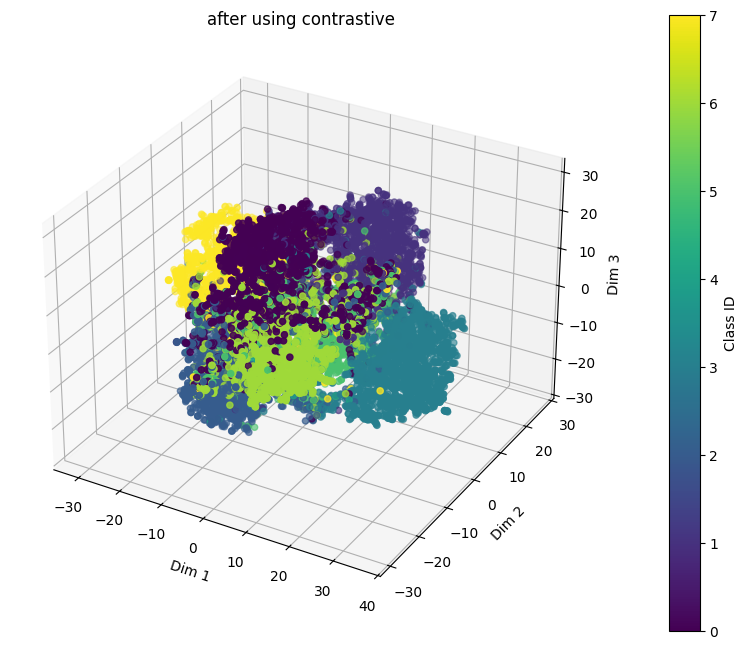

saved


In [ ]:
from tqdm.auto import tqdm

if __name__ == "__main__":
    
    torch.manual_seed(42)
    
    model  = MalDectModel(input_size=transformed.shape[1], 
                          hidden_dim=128, projection_dim=128)
    model = model.to(device)
    
    loss_fn = SupConLoss(temperature=.07)
    optimizer = torch.optim.Adam(params=model.parameters())

    epochs = 100
    
    start_train = timer()
    losses = train(model=model, loss_fn=loss_fn, optimizer=optimizer,
          dataLoader=data_loader, epochs=epochs)
    model_save_path = "F:\\university\\projects\\malware_api_detection_using_supcons\\mal-api-2019\supconModel_v2_ngram1.pth"
    torch.save(obj=model.state_dict(), f=model_save_path)
    print('saved')
    end_train = timer()

In [ ]:

plt.plot(range(epochs), losses)
plt.title("Training Loss over Epochs") 
plt.xlabel("Epochs")                   
plt.ylabel("Loss")                    
plt.show()